In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import config

In [2]:
df_train = pd.read_csv(config.path.Hp.train)
df_test = pd.read_csv(config.path.Hp.test)
display(df_train.shape)
display(df_train.duplicated().sum())
display(df_train.head(2))
display(df_test.shape)
display(df_test.duplicated().sum())
display(df_test.head(2))

(1460, 81)

np.int64(0)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


(1459, 80)

np.int64(0)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal


In [3]:
df_train.info()
display(df_train.select_dtypes(include=['float64']).columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

In [4]:
null_values = df_train.isna().sum().loc[lambda x: x > 0]
display(pd.DataFrame({
    'null_values': null_values.values,
    'dtype': df_train[null_values.index].dtypes,
    'unique_values': df_train[null_values.index].nunique()
}, index=null_values.index))
display(df_train[null_values.index].head(5))
# посмотреть nan распределение

,null_values,dtype,unique_values
LotFrontage,259,float64,110
Alley,1369,str,2
MasVnrType,872,str,3
MasVnrArea,8,float64,327
BsmtQual,37,str,4
BsmtCond,37,str,4
BsmtExposure,38,str,4
BsmtFinType1,37,str,6
BsmtFinType2,38,str,6
Electrical,1,str,5


,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
1,80.0,NaN,NaN,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
2,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
3,60.0,NaN,NaN,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
4,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN


In [7]:
num_cols = df_train.select_dtypes(include=['int', 'float']).columns.tolist()
cat_cols = df_train.select_dtypes(include=['str', 'category', 'object']).columns.tolist()
display(len(num_cols),
        len(cat_cols))
target = df_train['SalePrice']

38

43

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

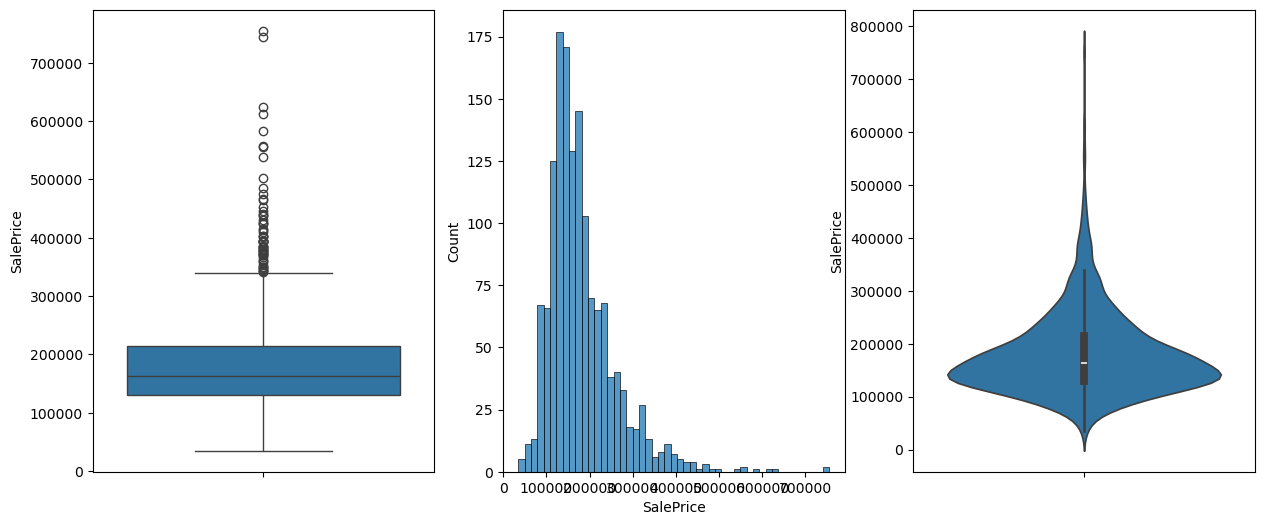

In [16]:
plt.figure(figsize=(15, 6))
plt.subplot(1,3,1)
sns.boxplot(target)
plt.subplot(1,3,2)
sns.histplot(target)
plt.subplot(1,3,3)
sns.violinplot(target)
display(target.describe())
plt.show()
# по таргету видно что выше ~340к можно сделать flag: 'high price'

In [9]:
display(df_train[num_cols].corr())
corr = df_train.drop(columns=['Id']).corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(11)
# # много корр фичей стоит подумать над основными и наиболее важными в контексте price на дом

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


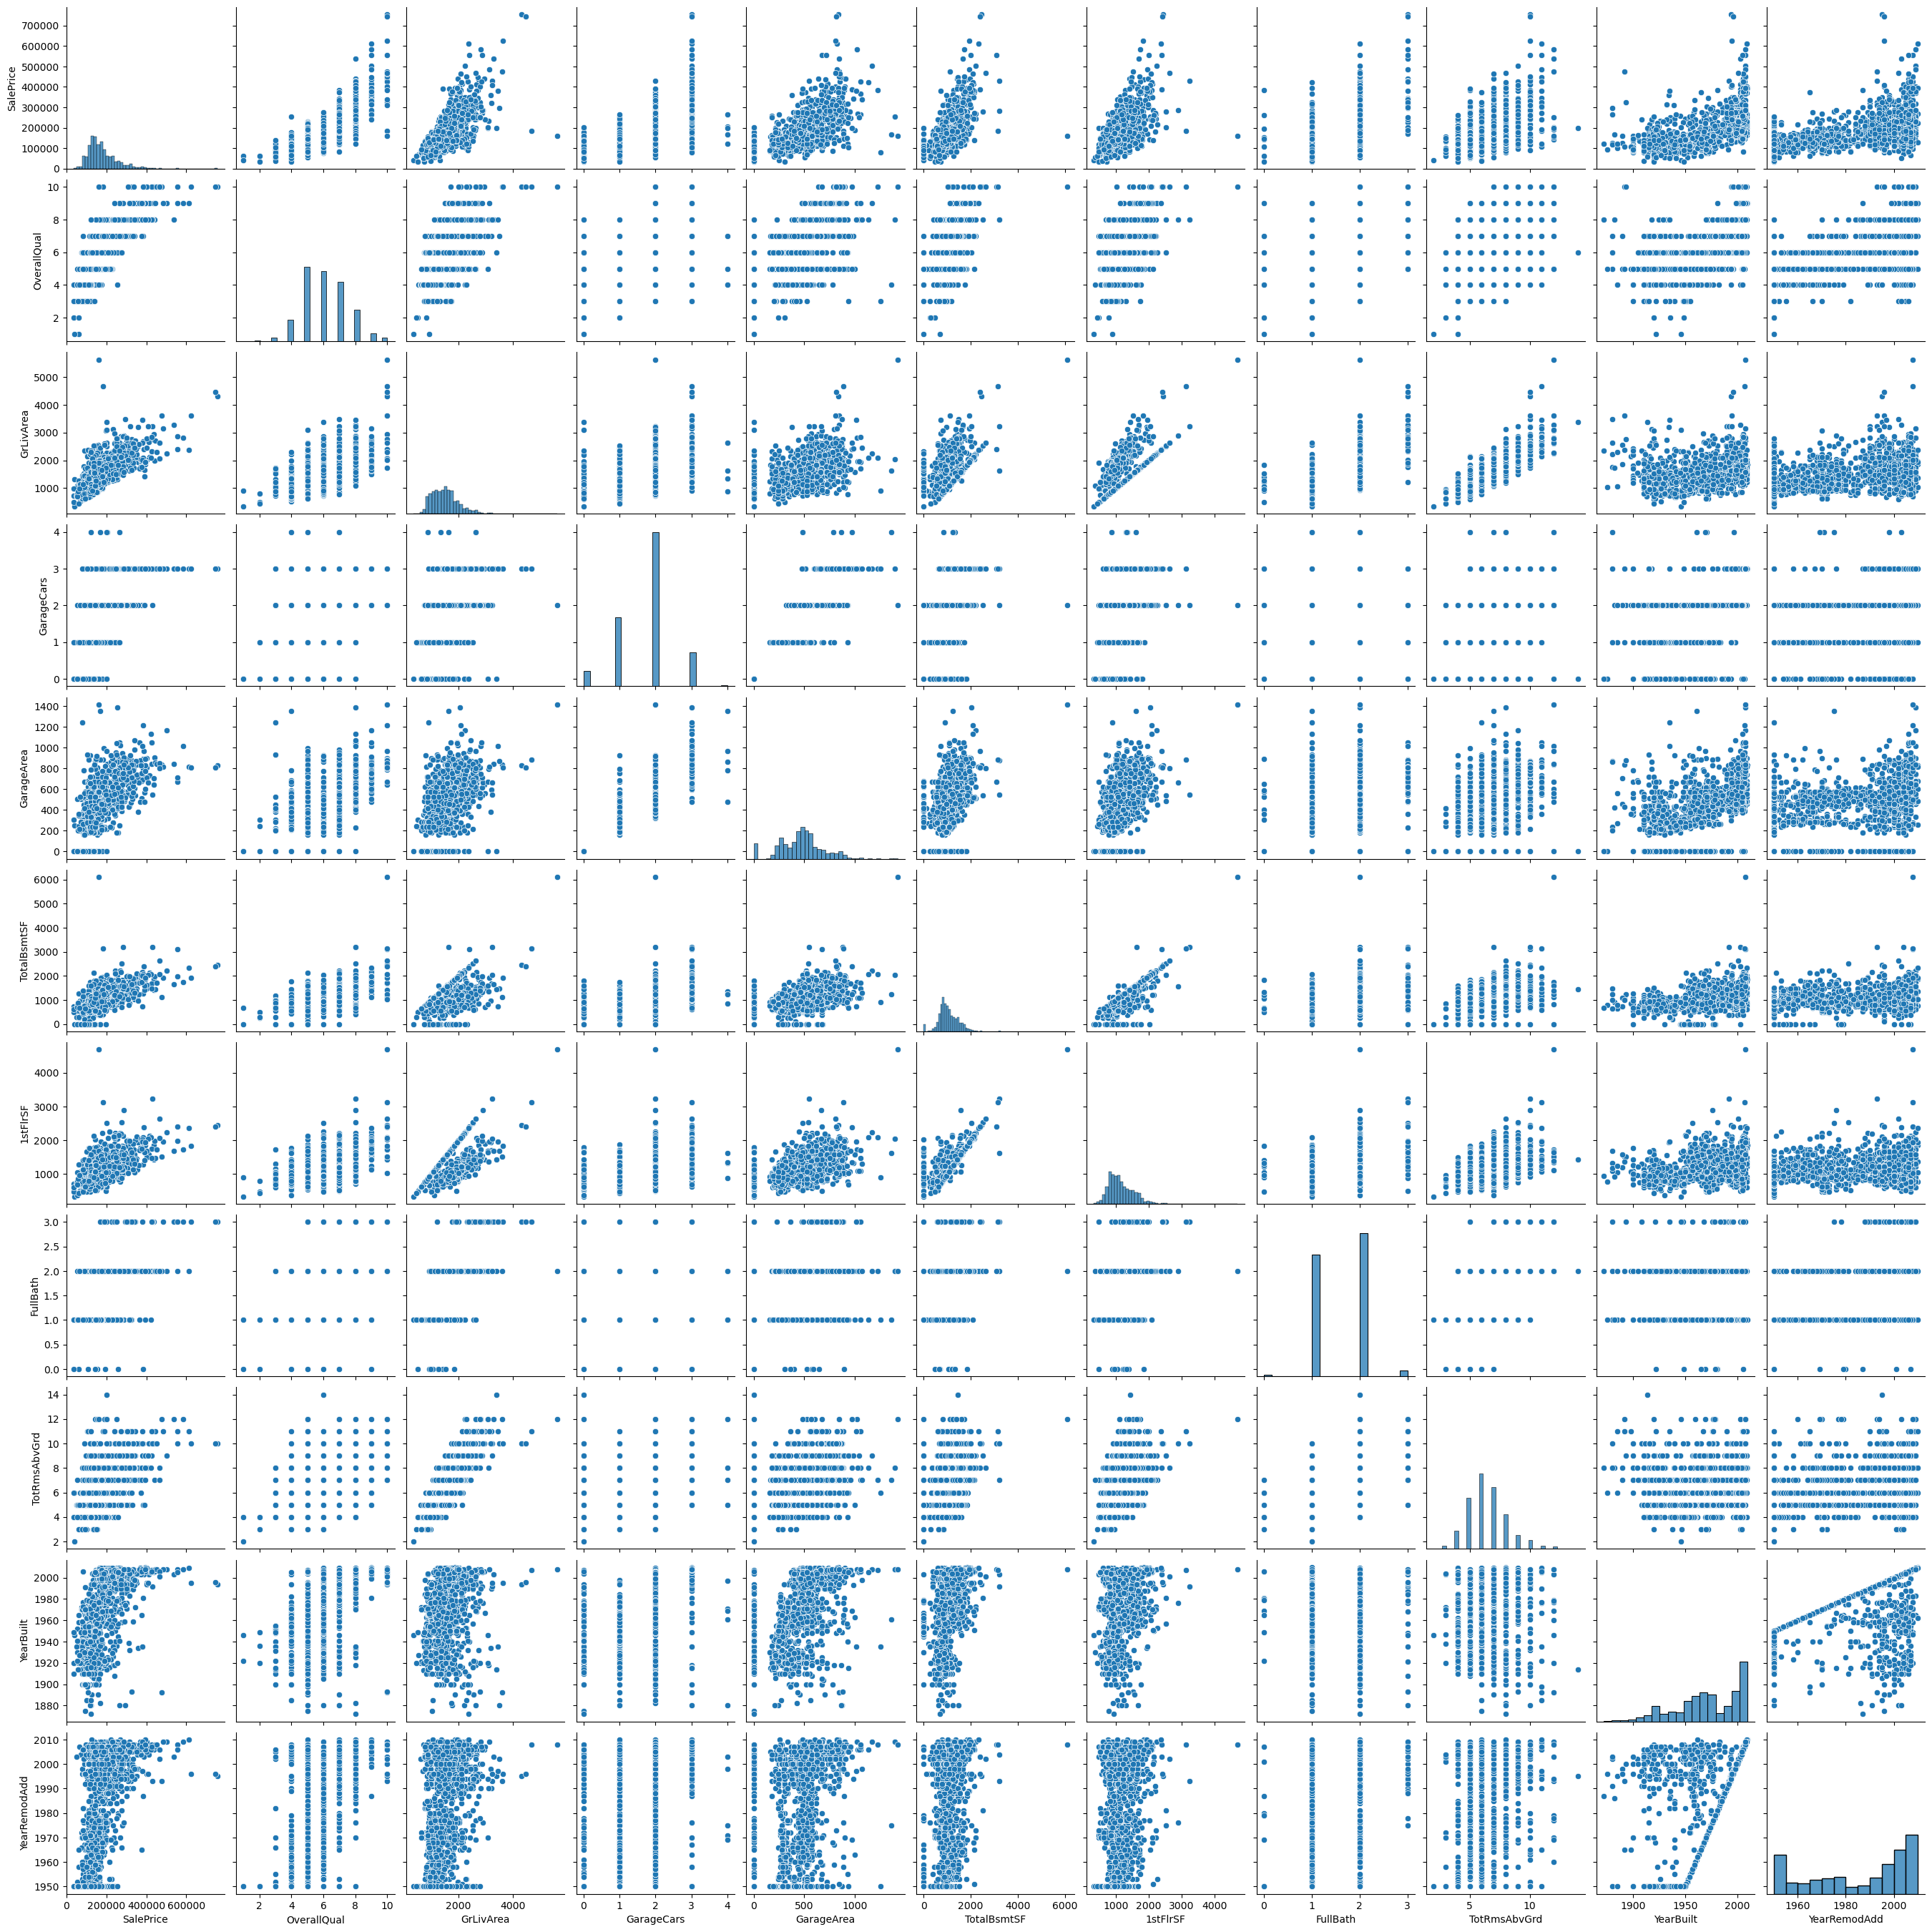

In [10]:
sns.pairplot(data = df_train[corr.index])
plt.show()

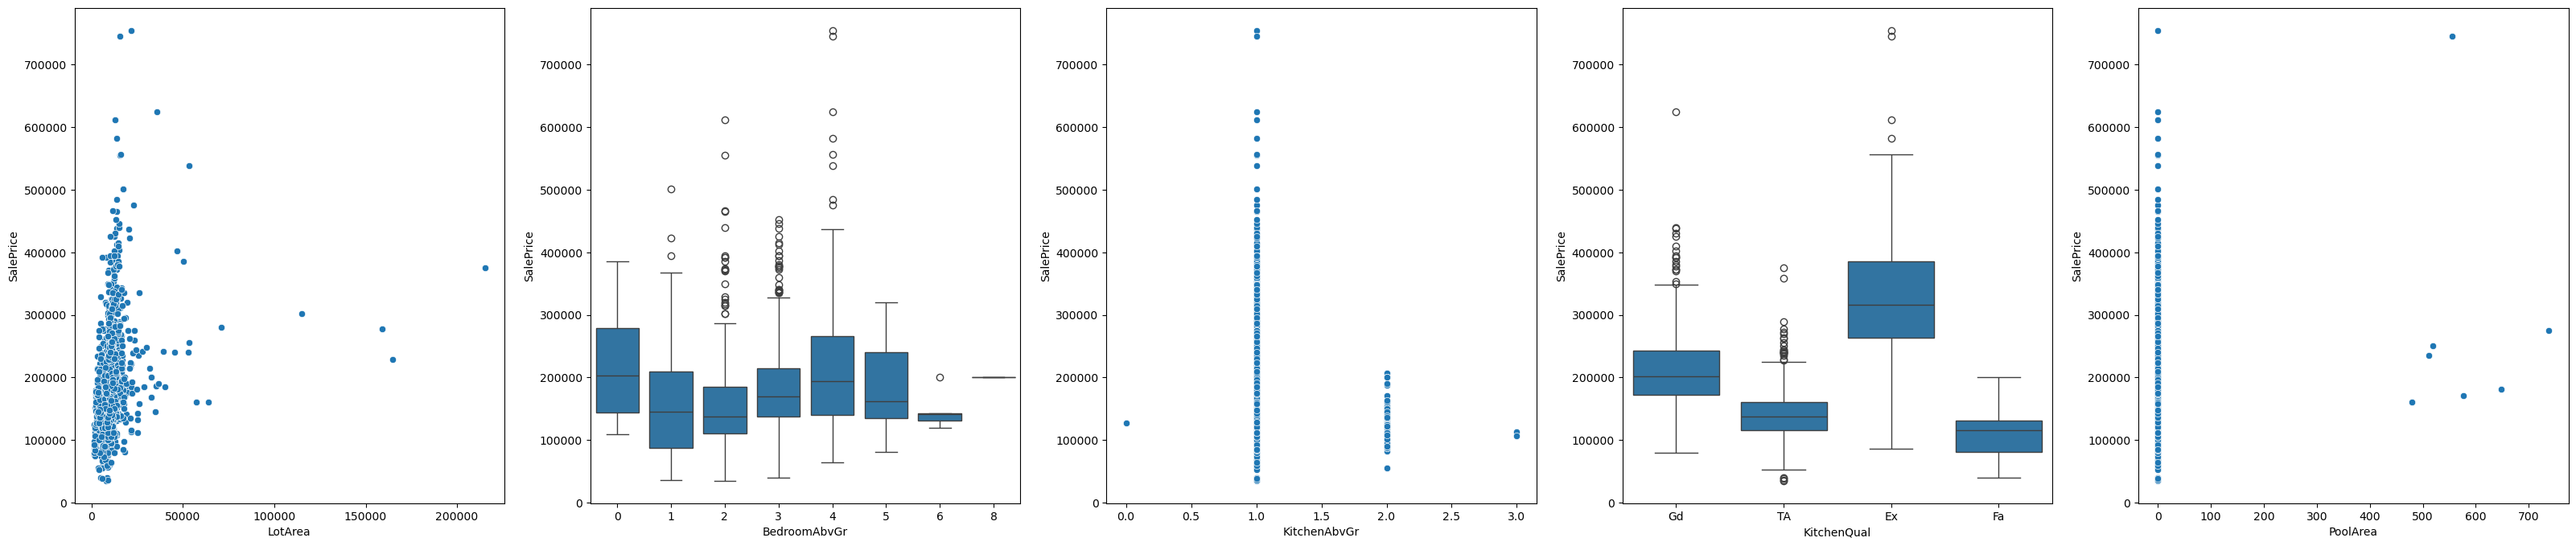

In [11]:
plt.figure(figsize=(40,8))
plt.subplot(1,5,1)
sns.scatterplot(data = df_train,
                x='LotArea',
                y=target)
plt.subplot(1,5,2)
sns.boxplot(data=df_train,
            x='BedroomAbvGr',
            y=target)
plt.subplot(1,5,3)
sns.scatterplot(data=df_train,
            x='KitchenAbvGr',
            y=target)
plt.subplot(1,5,4)
sns.boxplot(data=df_train,
            x='KitchenQual',
            y=target)
plt.subplot(1,5,5)
sns.scatterplot(data=df_train,
            x='PoolArea',
            y=target)
plt.show()

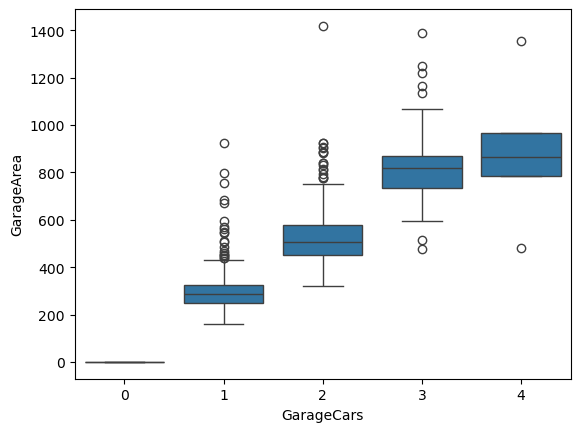

In [12]:
sns.boxplot(data=df_train,
                x='GarageCars',
                y='GarageArea')
plt.show()

In [ ]:
# с LotFrontage, MasVnrArea, GarageYrBlt -> работаем
# display(df_train['LotFrontage'].sort_values().head(5),
#         df_train['LotFrontage'].nunique(),
#         df_train['LotFrontage'].mean(),
#         df_train['LotFrontage'].median())


# решил делать median
# display(df_train['LotFrontage'].isna().sum())
# df_train['LotFrontage'] = df_train['LotFrontage'].fillna(df_train['LotFrontage'].median())
# display(df_train['LotFrontage'].isna().sum())

# display(df_train['MasVnrArea'].sort_values().head(5),
#         df_train['MasVnrArea'].nunique(),
#         df_train['MasVnrArea'].mean(),
#         df_train['MasVnrArea'].median())


# решил делать median
# display(df_train['MasVnrArea'].isna().sum())
# df_train['MasVnrArea'] = df_train['MasVnrArea'].fillna(df_train['MasVnrArea'].median())
# display(df_train['MasVnrArea'].isna().sum())



# display(df_train['GarageYrBlt'].sort_values().head(5), 
#         df_train['GarageYrBlt'].nunique(),
#         df_train['GarageYrBlt'].median())

# display(df_train['YearBuilt'].sort_values().head(5),
#         df_train['YearBuilt'].nunique(),
#         df_train['YearBuilt'].median(),
#         df_train['YearBuilt'].sort_values(ascending=False).head(5))

# display(df_train['YearRemodAdd'].sort_values().head(5),
#         df_train['YearRemodAdd'].nunique(),
#         df_train['YearRemodAdd'].median())

# решил сделать флаг:
# GarageYrBlt -> have_garage